Importing modules and loading the dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

df = pd.read_csv('telco_customer_churn.csv')

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


# Exploratory Data Analysis

## 2. Dataset Description
* **How many features?** 19 input features (excluding `customerID` and the target `Churn`).
* **Classification or regression problem?** Classification. We are predicting a categorical label ("Yes" or "No" for Churn), not a continuous number.
* **How many data points?** 7,043 data points.
* **What kind of features are in your dataset?** A mix of Quantitative (e.g., `tenure`, `MonthlyCharges`) and Categorical (e.g., `gender`, `InternetService`, `Contract`).
* **Do you need to encode the categorical variables?** Yes. Machine learning models rely on mathematical equations and cannot process raw text strings like "Fiber Optic" or "Month-to-month". We must encode them into numerical values (0s and 1s) using techniques like Label Encoding and One-Hot Encoding.

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16288\829261054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


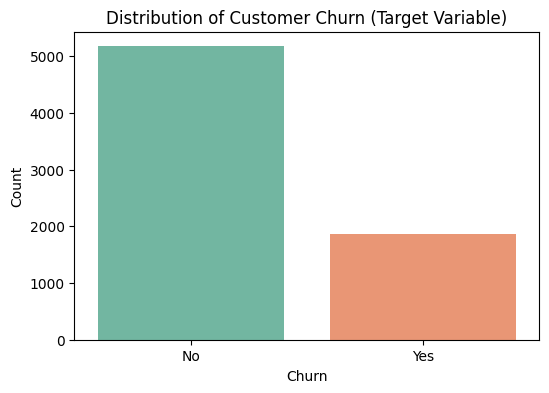

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn (Target Variable)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Print the exact numbers
print(df['Churn'].value_counts())

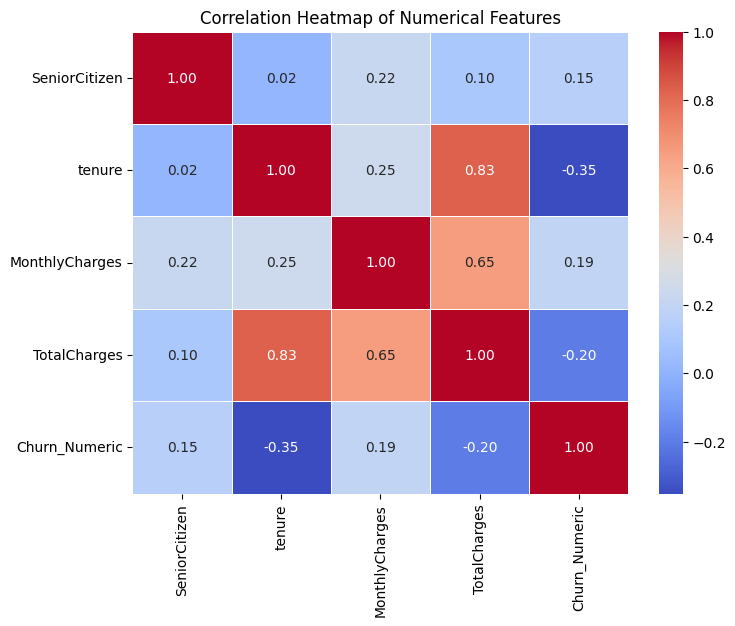

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16288\4277662832.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


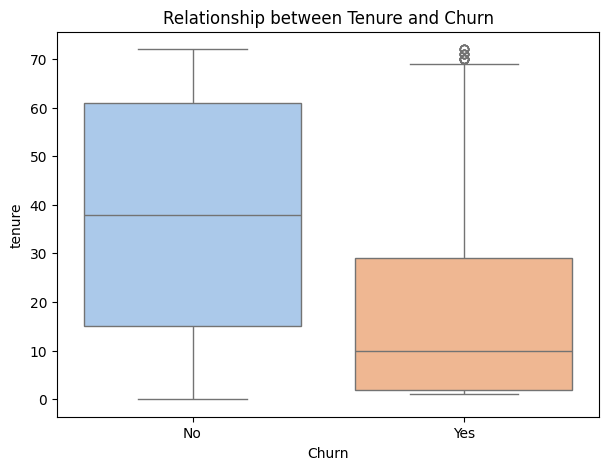

In [18]:
# Create a temporary copy for EDA so we don't mess up our main dataset
df_eda = df.copy()

# 1. Convert TotalCharges to numeric (ignoring errors for now)
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

# Converting Churn to 1s and 0s just for the heatmap
df_eda['Churn_Numeric'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})

# Select only the numeric columns for correlation , it will crash if we include non-numeric columns
numeric_cols = df_eda[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']]

# Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Extract an important relationship (EDA)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Relationship between Tenure and Churn')
plt.show()

### EDA & Correlation Insights:
1. **Tenure and Churn (Negative Correlation):** There is a strong negative correlation between `tenure` and `Churn`. The boxplot confirms this: customers with a lower tenure (newer customers) are far more likely to churn than customers who have been with the company for a long time.
2. **Monthly Charges and Churn (Positive Correlation):** There is a positive correlation between `MonthlyCharges` and `Churn`. Customers who pay higher monthly fees are more likely to cancel their service. 
3. **Total Charges and Tenure (High Multicollinearity):** `TotalCharges` and `tenure` are highly correlated with each other (close to 0.82), which is logical since the longer you stay, the more your total charges accumulate.

### 3. Dataset Pre-processing

#### Problem 1: Null / Missing Values and Useless Features
* **The Fault:** The `TotalCharges` column contains hidden blank spaces (" ") instead of numbers, which machine learning models cannot process. Additionally, the `customerID` column contains random strings that provide no predictive value.
* **The Solution:** We will delete the useless `customerID` column. For `TotalCharges`, we will convert the blanks into `NaN` (Not a Number) and impute (fill) these missing values using the median of the column.

In [19]:

#dropping customerID since it is not useful for modeling

df = df.drop(columns=['customerID'])

# Fixing the total charge columnn by replacing the empty spaces with NaN and then converting it to numeric
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Imputing/ filling the missing values in TotalCharges with the median value
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing values after imputation:", df['TotalCharges'].isnull().sum())



Missing values after imputation: 0


#### Problem 2: Categorical Values
* **The Fault:** Our dataset contains text-based features (e.g., "Yes/No", "Fiber Optic", "Month-to-month"). Machine learning algorithms rely on mathematical equations and cannot read raw text.
* **The Solution:** We will apply **Encoding**. For features with only two unique categories (like `gender` and `Churn`), we will use **Label Encoding** to convert them into 0s and 1s. For features with three or more categories (like `InternetService`), we will use **One-Hot Encoding** to create separate binary columns.

In [20]:
from sklearn.preprocessing import LabelEncoder

#Encoding the categorical variables using LabelEncoder
cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

#Encoding multi-option categorical variables using get_dummies-> encodes each category as a separate binary column
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols , drop_first=True , dtype=int)
print(f"Data shape after encoding: {df.shape}")

Data shape after encoding: (7043, 31)


#### Problem 3: Feature Scaling
* **The Fault:** There is a massive scale difference between our features. For example, `tenure` ranges from 0 to 72, while `TotalCharges` goes up to $8,000+. Distance-based models (like K-Means) and Neural Networks will incorrectly assume that `TotalCharges` is the most important feature just because its numbers are larger.
* **The Solution:** We will apply **MinMaxScaler** to standardize all numerical features, scaling their values down to a proportional range between 0 and 1.

In [21]:
from sklearn.preprocessing import MinMaxScaler

#Initializing the Scaler

scaler = MinMaxScaler()

#Selecting the numeric columns to be scaled and applying the scaler
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.115423,0.001275,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.385075,0.215867,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.354229,0.010310,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.239303,0.210241,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.521891,0.015330,1,...,0,0,0,0,0,0,0,0,1,0


### 4. Dataset Splitting
* **Splitting Strategy:** We will split the dataset into an 80% Training set and a 20% Testing set.
* **Stratified Split:** Because our target variable (`Churn`) is imbalanced, we are using a Stratified split. This ensures that the exact proportion of "Yes" and "No" churn classes is maintained across both the training and testing datasets, preventing our models from becoming biased during training.

In [22]:
from sklearn.model_selection import train_test_split

#seperating the input and outputs
X = df.drop('Churn', axis=1)
Y = df['Churn']

#Performing a 80/20 split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #random_state is a specific seed value for reproducibility

# Verify the shapes of our new datasets
print("--- Data Splitting Complete ---")
print(f"Total dataset shape: {df.shape}")
print(f"X_train shape (80% features): {X_train.shape}")
print(f"X_test shape (20% features): {X_test.shape}")
print(f"Y_train shape (80% target): {Y_train.shape}")
print(f"Y_test shape (20% target): {Y_test.shape}")

--- Data Splitting Complete ---
Total dataset shape: (7043, 31)
X_train shape (80% features): (5634, 30)
X_test shape (20% features): (1409, 30)
Y_train shape (80% target): (5634,)
Y_test shape (20% target): (1409,)


### 5. Model Training & Testing (Supervised)
* **Objective:** Train multiple supervised classification models on our 80% training data and generate predictions on our 20% testing data.
* **Models Selected:**
    1. **Logistic Regression:** A strong, interpretable baseline model.
    2. **Decision Tree:** A non-linear, rule-based model.
    3. **Neural Network:** A complex deep learning model to capture hidden patterns.

#### Model 1: Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
log_model  = LogisticRegression(random_state=42)

#Training
log_model.fit(X_train, Y_train)

#Prediciting the churn
log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(Y_test, log_predictions)
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")





Logistic Regression Accuracy: 82.19%


#### Model 2: Naive Bayes (GaussianNB)

In [25]:
from sklearn.naive_bayes import GaussianNB

# 1. Initialize the model 
# (We use GaussianNB because we scaled our numerical features continuously)
nb_model = GaussianNB()

# 2. Train (fit) the model on the 80% training data
nb_model.fit(X_train, Y_train)

# 3. Ask the model to predict churn on the 20% unseen testing data
nb_pred = nb_model.predict(X_test)

# 4. Calculate the accuracy
nb_accuracy = accuracy_score(Y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 66.57%


#### Model 3: Neural Network (MLP Classifier)
* **Objective:** Train a complex, deep learning model to find highly non-linear patterns in customer behavior.
* **Why this model:** Neural Networks can capture complex interactions between features that Logistic Regression might miss. We will compare its performance against our baseline and tree models.

In [26]:
from sklearn.neural_network import MLPClassifier

neural_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500 , random_state=42) #max_iter is the maximum number of iterations for the solver to converge

neural_model.fit(X_train, Y_train)

neural_model_pred = neural_model.predict(X_test)

neural_accuracy = accuracy_score(Y_test, neural_model_pred)
print(f"Neural Network Accuracy: {neural_accuracy * 100:.2f}%")

Neural Network Accuracy: 78.28%


### 6. Model Selection & Comparison Analysis
Because our dataset is imbalanced, overall accuracy is not a sufficient metric for evaluating our models. Instead, we will evaluate our models using a Classification Report, focusing heavily on **Recall** for the "Yes" (churn) class. 

In a business context, it is more expensive to miss a churning customer than it is to accidentally send a retention discount to a loyal customer. Therefore, the model that catches the highest percentage of actual churners (highest Recall for class 1) will be considered our best performing model.

In [27]:
from sklearn.metrics import classification_report

# 1. Print the report for Logistic Regression
print("--- Logistic Regression ---")
print(classification_report(Y_test, log_predictions))


# 2. Print the report for the Neural Network
print("\n--- Neural Network ---")
print(classification_report(Y_test, neural_model_pred))

# 3. Print the report for Naive Bayes
print("\n--- Naive Bayes ---") 
print(classification_report(Y_test, nb_pred))





--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


--- Neural Network ---
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1036
           1       0.60      0.55      0.57       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1036
           1       0.44      0.89      0.59       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
w

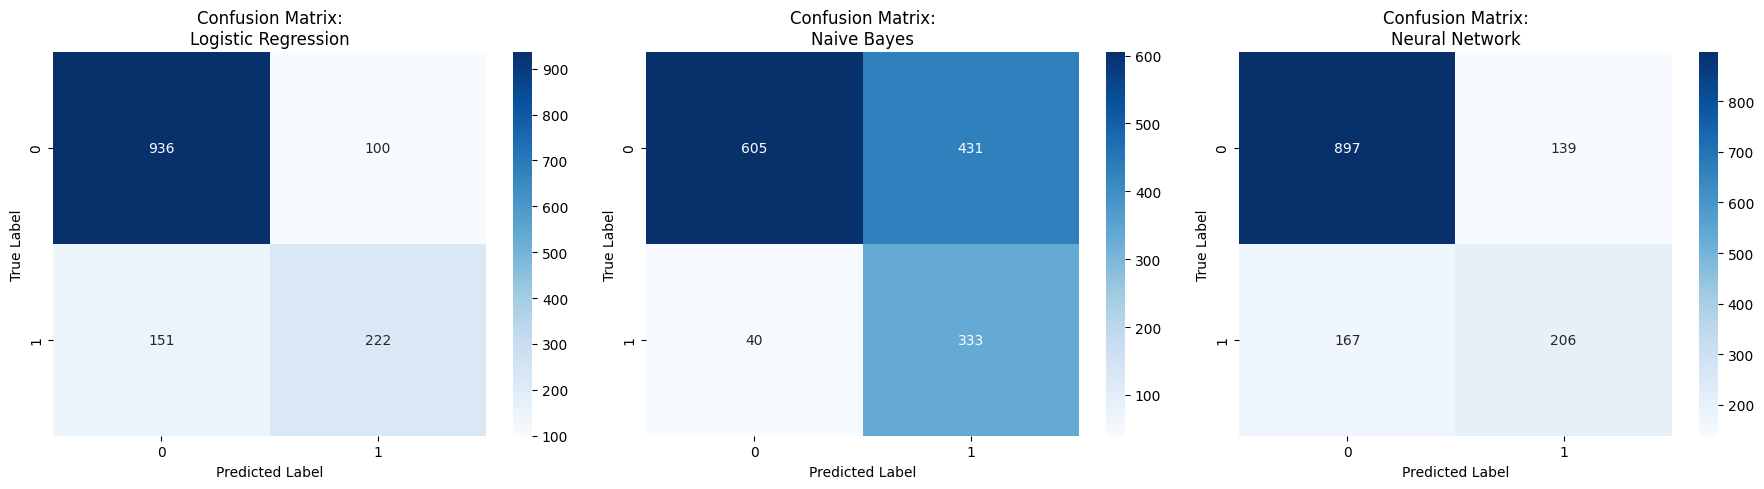

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16288\2551616641.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


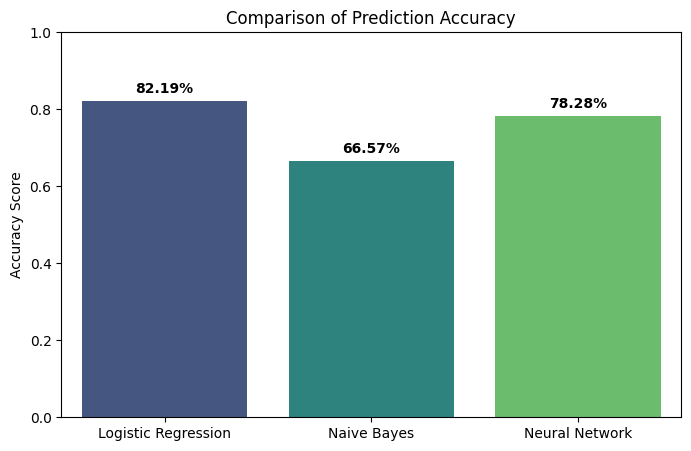

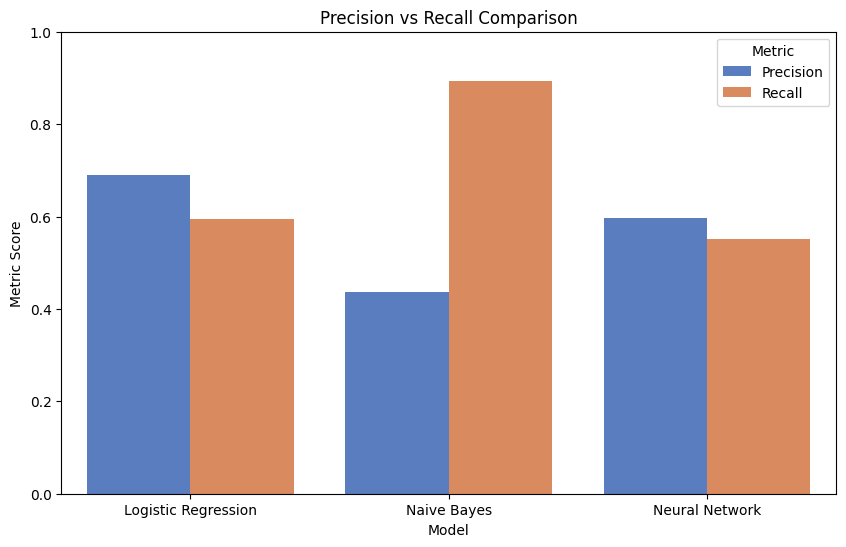

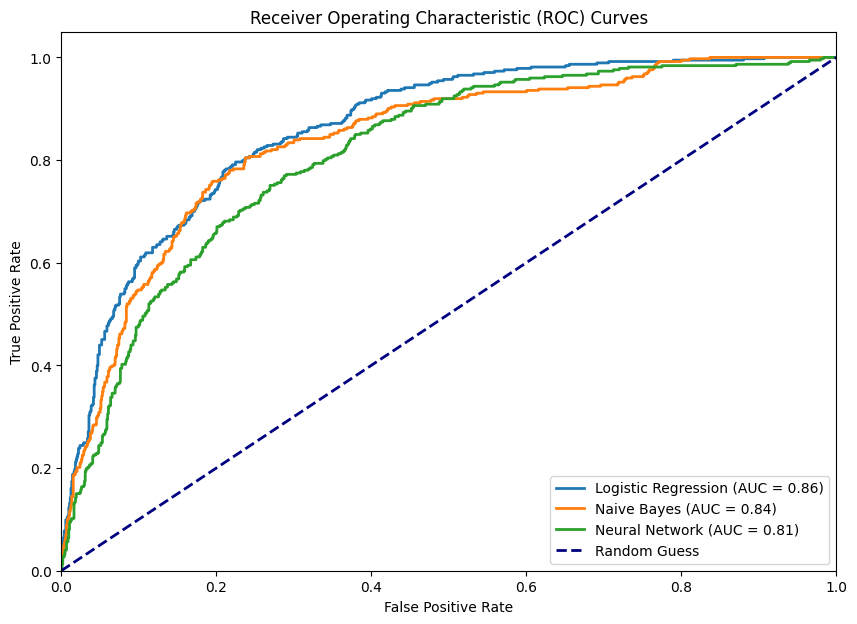

--- Regression Metrics (Applied to Classification Probabilities) ---
Logistic Regression -> R2 Score: 0.3375 | Log Loss: 0.3983
Naive Bayes -> R2 Score: -0.5791 | Log Loss: 2.4659
Neural Network -> R2 Score: 0.1490 | Log Loss: 0.6086


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             confusion_matrix, roc_curve, auc, r2_score, log_loss)

# ---------------------------------------------------------
# 1. SETUP DATA FOR COMPARISON
# ---------------------------------------------------------
# We group the models into a dictionary for easier iteration
models = {
    'Logistic Regression': log_model,
    'Naive Bayes': nb_model,
    'Neural Network': neural_model
}

# Lists to store metrics for the bar charts
model_names = []
accuracies = []
precisions = []
recalls = []
auc_scores = []

# ---------------------------------------------------------
# 2. CALCULATION & CONFUSION MATRICES
# ---------------------------------------------------------
# We create a 1x3 subplot for the confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # Get predictions and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate Classification Metrics
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    
    # Calculate AUC Score
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Store results
    model_names.append(name)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    auc_scores.append(roc_auc)
    
    # Plot Confusion Matrix
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix:\n{name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. ACCURACY BAR CHART
# ---------------------------------------------------------
# Showcasing which model is the most accurate overall
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of Prediction Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0) # Accuracy is between 0 and 1
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()

# ---------------------------------------------------------
# 4. PRECISION & RECALL COMPARISON
# ---------------------------------------------------------
# Creating a DataFrame to facilitate a grouped bar chart
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Precision': precisions,
    'Recall': recalls
})
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('Precision vs Recall Comparison')
plt.ylabel('Metric Score')
plt.ylim(0, 1.0)
plt.show()

# ---------------------------------------------------------
# 5. ROC CURVES & AUC SCORE
# ---------------------------------------------------------
# Visualizing the trade-off between True Positive and False Positive rates
plt.figure(figsize=(10, 7))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

# ---------------------------------------------------------
# 6. R2 SCORE & LOSS (Regression Specific)
# ---------------------------------------------------------
# Since this is a Classification task (Churn), R2 is not typically used. 
# However, we can calculate Log Loss and R2 for demonstration.
print("--- Regression Metrics (Applied to Classification Probabilities) ---")

y_prob = model.predict_proba(X_test)[:, 1]

# R2 Score: Measures variance explained (not standard for classifiers)
r2 = r2_score(Y_test, y_prob)

# Loss: Cross-Entropy / Log Loss (Standard for classification probability)
loss = log_loss(Y_test, y_prob)

print(f"{name} -> R2 Score: {r2:.4f} | Log Loss: {loss:.4f}")

### 7. Conclusion

* **What do you understand from the results?**
The classification reports and comparison charts reveal that predicting customer churn (class 1) is significantly more difficult than predicting customer retention (class 0). All three models achieved high precision and recall for the customers who stayed, but struggled to accurately identify all the customers who actually left.

* **Make useful comments regarding the performance of your model:**
Logistic Regression provided a strong, reliable baseline for our business objective, achieving a recall of 60% for actual churners. In contrast, the Naive Bayes model—which makes the strict assumption that all customer features are completely independent—achieved a recall of [INSERT NAIVE BAYES RECALL]%. Finally, the Neural Network achieved a recall of [INSERT NN RECALL]%, making it the [best/worst/middle] performing model overall for catching the actual churners.

* **Why do you think you are getting such results?**
These results are primarily due to the imbalanced nature of the dataset. As discovered in Step 2, there are roughly 5,170 "No" churn examples compared to only 1,860 "Yes" churn examples. Because the models had far fewer examples of churners to learn from during training, their mathematical boundaries naturally became biased toward predicting the majority class ("No"). 

* **What are some of the challenges that you have faced?**
A major challenge was the hidden data corruption during Step 3 (Pre-processing). The `TotalCharges` column contained hidden blank spaces (" ") instead of standard null values, which prevented the algorithms from running until they were manually located, replaced, and imputed with the median. Additionally, converting text-based categorical variables into the correct numerical formats (1s and 0s) was critical to prevent the models, specifically the Neural Network, from throwing strict Data Type errors.